In [1]:
# Show plots inline, and load main getdist plot module and samples class
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

# import libraries:
import sys, os
os.environ['TF_USE_LEGACY_KERAS'] = '1'  # needed for tensorflow KERAS compatibility
os.environ['DISPLAY'] = 'inline'  # hack to get getdist working
sys.path.insert(0,os.path.realpath(os.path.join(os.getcwd(),'../tensiometer')))
from getdist import plots, MCSamples
from getdist.gaussian_mixtures import GaussianND
import getdist
getdist.chains.print_load_details = False
import scipy
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# tensorflow imports:
import tensorflow as tf
import tensorflow_probability as tfp

print(sys.path)

# import the tensiometer tools that we need:
import tensiometer
#from tensiometer.utilities import stats_utilities as utilities # error
from tensiometer import utilities
from tensiometer.synthetic_probability import synthetic_probability as sp

# getdist settings to ensure consistency of plots:
getdist_settings = {'ignore_rows': 0.4, 
                    'smooth_scale_2D': 0.3,
                    'smooth_scale_1D': 0.3,
                    }    

2025-06-25 15:12:29.467578: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-25 15:12:29.631964: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-25 15:12:29.666771: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-25 15:12:29.677153: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-25 15:12:29.702646: I tensorflow/core/platform/cpu_feature_guar

['/auto_farm/farm_fs/mraveri/projects/marialuisa/tensiometer', '/home/mraveri/software/anaconda3/envs/mlg/lib/python39.zip', '/home/mraveri/software/anaconda3/envs/mlg/lib/python3.9', '/home/mraveri/software/anaconda3/envs/mlg/lib/python3.9/lib-dynload', '', '/home/mraveri/.local/lib/python3.9/site-packages', '/home/mraveri/.local/lib/python3.9/site-packages/tensorflow_probability-0.24.0-py3.9.egg', '/home/mraveri/.local/lib/python3.9/site-packages/gast-0.4.0-py3.9.egg', '/home/mraveri/.local/lib/python3.9/site-packages/pymanopt-0.2.5-py3.9.egg', '/home/mraveri/.local/lib/python3.9/site-packages/sphinx_rtd_theme-3.0.1-py3.9.egg', '/home/mraveri/.local/lib/python3.9/site-packages/joblib-1.4.2-py3.9.egg', '/home/mraveri/.local/lib/python3.9/site-packages/dm_tree-0.1.8-py3.9-linux-x86_64.egg', '/home/mraveri/.local/lib/python3.9/site-packages/cloudpickle-3.1.0-py3.9.egg', '/home/mraveri/.local/lib/python3.9/site-packages/absl_py-2.1.0-py3.9.egg', '/home/mraveri/.local/lib/python3.9/site-p

In [2]:
# ADD MY CHAINS:
# Loading samples
#PLANCK_ALL
#lcdm:
chain_lcdm = os.path.join('/home/mraveri/projects/andrea/tesi_magistrale/lcdm/planck_all', '1_lcdm_planck_desidr2_des')
samples_lcdm = getdist.mcsamples.loadMCSamples(file_root=chain_lcdm, settings=getdist_settings)
#print('Parameters: ', samples.paramNames.names)
param_names_lcdm = [param.name for param in samples_lcdm.paramNames.names]
print(param_names_lcdm)

#w0wacdm:
chain_w0wa = os.path.join('/home/mraveri/projects/andrea/tesi_magistrale/w0wacdm/all_planck/first_attempt', '1_w0wa_planck_desidr2_des')
samples_w0wa = getdist.mcsamples.loadMCSamples(file_root=chain_w0wa, settings=getdist_settings)
#print('Parameters: ', samples.paramNames.names)
param_names_w0wa = [param.name for param in samples_w0wa.paramNames.names]
print(param_names_w0wa)

#EFT_exp:
chain_exp = os.path.join('/home/mraveri/projects/andrea/tesi_magistrale/eftcamb/eftcamb_exponential/lcdm_eft_exp/planck_all/first_attempt', '1_EXP_planck_desidr2_des')
samples_exp = getdist.mcsamples.loadMCSamples(file_root=chain_exp, settings=getdist_settings)
#print('Parameters: ', samples.paramNames.names)
param_names_exp = [param.name for param in samples_exp.paramNames.names]
print(param_names_exp)

'''
#ACT_ALL
#lcdm:
chain_lcdm = os.path.join('/home/andrewcats/tesi_magistrale/lcdm/act_all', '1_lcdm_act_planck_desidr2_des')
samples_lcdm = getdist.mcsamples.loadMCSamples(file_root=chain_lcdm, settings=getdist_settings)
#print('Parameters: ', samples.paramNames.names)
param_names_lcdm = [param.name for param in samples_lcdm.paramNames.names]
print(param_names_lcdm)

#w0wacdm:
chain_w0wa = os.path.join('/home/andrewcats/tesi_magistrale/w0wacdm/act_all', '1_w0wa_act_planck_desidr2_des')
samples_w0wa = getdist.mcsamples.loadMCSamples(file_root=chain_w0wa, settings=getdist_settings)
#print('Parameters: ', samples.paramNames.names)
param_names_w0wa = [param.name for param in samples_w0wa.paramNames.names]
print(param_names_w0wa)

#EFT_exp:
chain_exp = os.path.join('/home/andrewcats/tesi_magistrale/eftcamb/eftcamb_exponential/lcdm_eft_exp/act_all', '1_EXP_act_planck_desidr2_des')
samples_exp = getdist.mcsamples.loadMCSamples(file_root=chain_exp, settings=getdist_settings)
#print('Parameters: ', samples.paramNames.names)
param_names_exp = [param.name for param in samples_exp.paramNames.names]
print(param_names_exp)
'''

['logA', 'ns', 'theta_MC_100', 'ombh2', 'omch2', 'tau', 'A_planck', 'cal100A', 'cal100B', 'cal143B', 'cal217A', 'cal217B', 'Aradio', 'Adusty', 'AdustT', 'beta_dustT', 'Acib', 'beta_cib', 'Atsz', 'Aksz', 'xi', 'AdustP', 'beta_dustP', 'A', 'As', 'DHBBN', 'YHe', 'Y_p', 'age', 'clamp', 'H0', 'omegam', 'omegamh2', 'zre', 'sigma8', 's8h5', 's8omegamp5', 's8omegamp25', 'rdrag', 'beta_dusty', 'chi2__BAO', 'chi2__CMB', 'chi2__SN', 'minuslogprior', 'minuslogprior__0', 'chi2', 'chi2__sn.desy5', 'chi2__bao.desi_dr2.desi_bao_all', 'chi2__planck_2018_lowl.TT', 'chi2__planck_2020_lollipop.lowlB', 'chi2__planck_2020_lollipop.lowlEB', 'chi2__planck_2020_hillipop.TTTEEE']
['logA', 'ns', 'theta_MC_100', 'ombh2', 'omch2', 'tau', 'w', 'wa', 'A_planck', 'cal100A', 'cal100B', 'cal143B', 'cal217A', 'cal217B', 'Aradio', 'Adusty', 'AdustT', 'beta_dustT', 'Acib', 'beta_cib', 'Atsz', 'Aksz', 'xi', 'AdustP', 'beta_dustP', 'A', 'As', 'DHBBN', 'YHe', 'Y_p', 'age', 'clamp', 'H0', 'omegam', 'omegamh2', 'zre', 'sigma8'

"\n#ACT_ALL\n#lcdm:\nchain_lcdm = os.path.join('/home/andrewcats/tesi_magistrale/lcdm/act_all', '1_lcdm_act_planck_desidr2_des')\nsamples_lcdm = getdist.mcsamples.loadMCSamples(file_root=chain_lcdm, settings=getdist_settings)\n#print('Parameters: ', samples.paramNames.names)\nparam_names_lcdm = [param.name for param in samples_lcdm.paramNames.names]\nprint(param_names_lcdm)\n\n#w0wacdm:\nchain_w0wa = os.path.join('/home/andrewcats/tesi_magistrale/w0wacdm/act_all', '1_w0wa_act_planck_desidr2_des')\nsamples_w0wa = getdist.mcsamples.loadMCSamples(file_root=chain_w0wa, settings=getdist_settings)\n#print('Parameters: ', samples.paramNames.names)\nparam_names_w0wa = [param.name for param in samples_w0wa.paramNames.names]\nprint(param_names_w0wa)\n\n#EFT_exp:\nchain_exp = os.path.join('/home/andrewcats/tesi_magistrale/eftcamb/eftcamb_exponential/lcdm_eft_exp/act_all', '1_EXP_act_planck_desidr2_des')\nsamples_exp = getdist.mcsamples.loadMCSamples(file_root=chain_exp, settings=getdist_settings)

In [3]:
'''
kwargs = {
          'feedback': 2,
          'plot_every': 1000,
          'pop_size': 1,
          #'cache_dir': 'test',  # set this to a directory to cache the results
          #'root_name': 'test',  # sets the name of the flow for the cache files
        }

flow_lcdm = sp.flow_from_chain(samples_lcdm,  # parameter difference chain
                          **kwargs)

flow_w0wa = sp.flow_from_chain(samples_w0wa,  # parameter difference chain
                          **kwargs)

flow_exp = sp.flow_from_chain(samples_exp,  # parameter difference chain
                          **kwargs)
'''

"\nkwargs = {\n          'feedback': 2,\n          'plot_every': 1000,\n          'pop_size': 1,\n          #'cache_dir': 'test',  # set this to a directory to cache the results\n          #'root_name': 'test',  # sets the name of the flow for the cache files\n        }\n\nflow_lcdm = sp.flow_from_chain(samples_lcdm,  # parameter difference chain\n                          **kwargs)\n\nflow_w0wa = sp.flow_from_chain(samples_w0wa,  # parameter difference chain\n                          **kwargs)\n\nflow_exp = sp.flow_from_chain(samples_exp,  # parameter difference chain\n                          **kwargs)\n"

In [4]:
'''
# we can plot training summaries to make sure training went smoothly:
flow_lcdm.training_plot()

flow_w0wa.training_plot()

flow_exp.training_plot()
'''

'\n# we can plot training summaries to make sure training went smoothly:\nflow_lcdm.training_plot()\n\nflow_w0wa.training_plot()\n\nflow_exp.training_plot()\n'

In [5]:
'''
# and we can print the training summary:
flow_lcdm.print_training_summary()

flow_w0wa.print_training_summary()

flow_exp.print_training_summary()
'''

'\n# and we can print the training summary:\nflow_lcdm.print_training_summary()\n\nflow_w0wa.print_training_summary()\n\nflow_exp.print_training_summary()\n'

In [6]:
'''
# we can triangle plot the flow to see how well it has learned the target distribution:
g_lcdm = plots.get_subplot_plotter()
g_lcdm.triangle_plot([samples_lcdm, flow_lcdm.MCSamples(20000)], 
                params=flow_lcdm.param_names,
                filled=True)

g_w0wa = plots.get_subplot_plotter()
g_w0wa.triangle_plot([samples_w0wa, flow_w0wa.MCSamples(20000)], 
                params=flow_w0wa.param_names,
                filled=True)

g_exp = plots.get_subplot_plotter()
g_exp.triangle_plot([samples_exp, flow_exp.MCSamples(20000)], 
                params=flow_exp.param_names,
                filled=True)
'''

'\n# we can triangle plot the flow to see how well it has learned the target distribution:\ng_lcdm = plots.get_subplot_plotter()\ng_lcdm.triangle_plot([samples_lcdm, flow_lcdm.MCSamples(20000)], \n                params=flow_lcdm.param_names,\n                filled=True)\n\ng_w0wa = plots.get_subplot_plotter()\ng_w0wa.triangle_plot([samples_w0wa, flow_w0wa.MCSamples(20000)], \n                params=flow_w0wa.param_names,\n                filled=True)\n\ng_exp = plots.get_subplot_plotter()\ng_exp.triangle_plot([samples_exp, flow_exp.MCSamples(20000)], \n                params=flow_exp.param_names,\n                filled=True)\n'

Re-do:

In [7]:
'''
# this looks nice but not perfect, let's train for longer:
flow_lcdm.feedback = 1
flow_lcdm.train(epochs=300, verbose=-1);  # verbose = -1 uses tqdm progress bar

flow_w0wa.feedback = 1
flow_w0wa.train(epochs=300, verbose=-1);  # verbose = -1 uses tqdm progress bar

flow_exp.feedback = 1
flow_exp.train(epochs=300, verbose=-1);  # verbose = -1 uses tqdm progress bar
'''

"\n# this looks nice but not perfect, let's train for longer:\nflow_lcdm.feedback = 1\nflow_lcdm.train(epochs=300, verbose=-1);  # verbose = -1 uses tqdm progress bar\n\nflow_w0wa.feedback = 1\nflow_w0wa.train(epochs=300, verbose=-1);  # verbose = -1 uses tqdm progress bar\n\nflow_exp.feedback = 1\nflow_exp.train(epochs=300, verbose=-1);  # verbose = -1 uses tqdm progress bar\n"

In [8]:
# we can plot training summaries to make sure training went smoothly:
#flow_lcdm.training_plot()

In [9]:
#flow_w0wa.training_plot()

In [10]:
#flow_exp.training_plot()

In [11]:
'''
# we can triangle plot the flow to see how well it has learned the target distribution:
g_lcdm = plots.get_subplot_plotter()
g_lcdm.triangle_plot([samples_lcdm, 
                 flow_lcdm.MCSamples(20000)  # this flow method returns a MCSamples object
                 ], 
                params=flow_lcdm.param_names,
                filled=True)

g_w0wa = plots.get_subplot_plotter()
g_w0wa.triangle_plot([samples_w0wa, 
                 flow_w0wa.MCSamples(20000)  # this flow method returns a MCSamples object
                 ], 
                params=flow_w0wa.param_names,
                filled=True)

g_exp = plots.get_subplot_plotter()
g_exp.triangle_plot([samples_exp, 
                 flow_exp.MCSamples(20000)  # this flow method returns a MCSamples object
                 ], 
                params=flow_exp.param_names,
                filled=True)
'''

'\n# we can triangle plot the flow to see how well it has learned the target distribution:\ng_lcdm = plots.get_subplot_plotter()\ng_lcdm.triangle_plot([samples_lcdm, \n                 flow_lcdm.MCSamples(20000)  # this flow method returns a MCSamples object\n                 ], \n                params=flow_lcdm.param_names,\n                filled=True)\n\ng_w0wa = plots.get_subplot_plotter()\ng_w0wa.triangle_plot([samples_w0wa, \n                 flow_w0wa.MCSamples(20000)  # this flow method returns a MCSamples object\n                 ], \n                params=flow_w0wa.param_names,\n                filled=True)\n\ng_exp = plots.get_subplot_plotter()\ng_exp.triangle_plot([samples_exp, \n                 flow_exp.MCSamples(20000)  # this flow method returns a MCSamples object\n                 ], \n                params=flow_exp.param_names,\n                filled=True)\n'

This is now much better

In [12]:
'''
ev_lcdm, eer_lcdm = flow_lcdm.evidence(weighted=True)
print(f'LCDM: log(Z) = {ev_lcdm} +- {eer_lcdm}')

ev_w0wa, eer_w0wa = flow_w0wa.evidence(weighted=True)
print(f'W0WA: log(Z) = {ev_w0wa} +- {eer_w0wa}')

ev_exp, eer_exp = flow_exp.evidence(weighted=True)
print(f'EXP: log(Z) = {ev_exp} +- {eer_exp}')
'''

"\nev_lcdm, eer_lcdm = flow_lcdm.evidence(weighted=True)\nprint(f'LCDM: log(Z) = {ev_lcdm} +- {eer_lcdm}')\n\nev_w0wa, eer_w0wa = flow_w0wa.evidence(weighted=True)\nprint(f'W0WA: log(Z) = {ev_w0wa} +- {eer_w0wa}')\n\nev_exp, eer_exp = flow_exp.evidence(weighted=True)\nprint(f'EXP: log(Z) = {ev_exp} +- {eer_exp}')\n"

# FARLO CON AVERAGE 

In [13]:
kwargs = {
          'feedback': 1,
          'verbose': -1,
          'plot_every': 1000,
          'pop_size': 1,
          'num_flows': 3,
          'epochs': 300,
          'loss_mode': 'annealed'
        }

average_flow_lcdm = sp.average_flow_from_chain(samples_lcdm,  # parameter difference chain
                                          **kwargs)

Training flow 0


2025-06-25 15:13:44.505227: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 970 MB memory:  -> device: 0, name: NVIDIA A40, pci bus id: 0000:31:00.0, compute capability: 8.6
2025-06-25 15:13:44.507632: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 43333 MB memory:  -> device: 1, name: NVIDIA A40, pci bus id: 0000:4b:00.0, compute capability: 8.6
2025-06-25 15:13:44.510874: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 43333 MB memory:  -> device: 2, name: NVIDIA A40, pci bus id: 0000:b1:00.0, compute capability: 8.6
2025-06-25 15:13:44.514262: I tensorflow/core/common_runtime/gpu/gpu_device.cc:2021] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 43333 MB memory:  -> device: 3, name: NVIDIA A40, pci bus id: 0000:ca:00.0, compute capability: 8.6
20

0epoch [00:00, ?epoch/s]

I0000 00:00:1750857255.491858 1343795 service.cc:146] XLA service 0x7fa2d7d17240 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1750857255.491903 1343795 service.cc:154]   StreamExecutor device (0): NVIDIA A40, Compute Capability 8.6
I0000 00:00:1750857255.491912 1343795 service.cc:154]   StreamExecutor device (1): NVIDIA A40, Compute Capability 8.6
I0000 00:00:1750857255.491915 1343795 service.cc:154]   StreamExecutor device (2): NVIDIA A40, Compute Capability 8.6
I0000 00:00:1750857255.491918 1343795 service.cc:154]   StreamExecutor device (3): NVIDIA A40, Compute Capability 8.6
2025-06-25 15:14:15.503264: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-06-25 15:14:15.548016: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8907
I0000 00:00:1750857255.644021 1343795 device_compiler.h:1

Training flow 1


0epoch [00:00, ?epoch/s]

Training flow 2


0epoch [00:00, ?epoch/s]

In [14]:
average_flow_w0wa = sp.average_flow_from_chain(samples_w0wa,  # parameter difference chain
                                          **kwargs)

Training flow 0


0epoch [00:00, ?epoch/s]

Training flow 1


0epoch [00:00, ?epoch/s]

Training flow 2


0epoch [00:00, ?epoch/s]

In [15]:
average_flow_exp = sp.average_flow_from_chain(samples_exp,  # parameter difference chain
                                          **kwargs)

Training flow 0


0epoch [00:00, ?epoch/s]

Training flow 1


0epoch [00:00, ?epoch/s]

Training flow 2


0epoch [00:00, ?epoch/s]

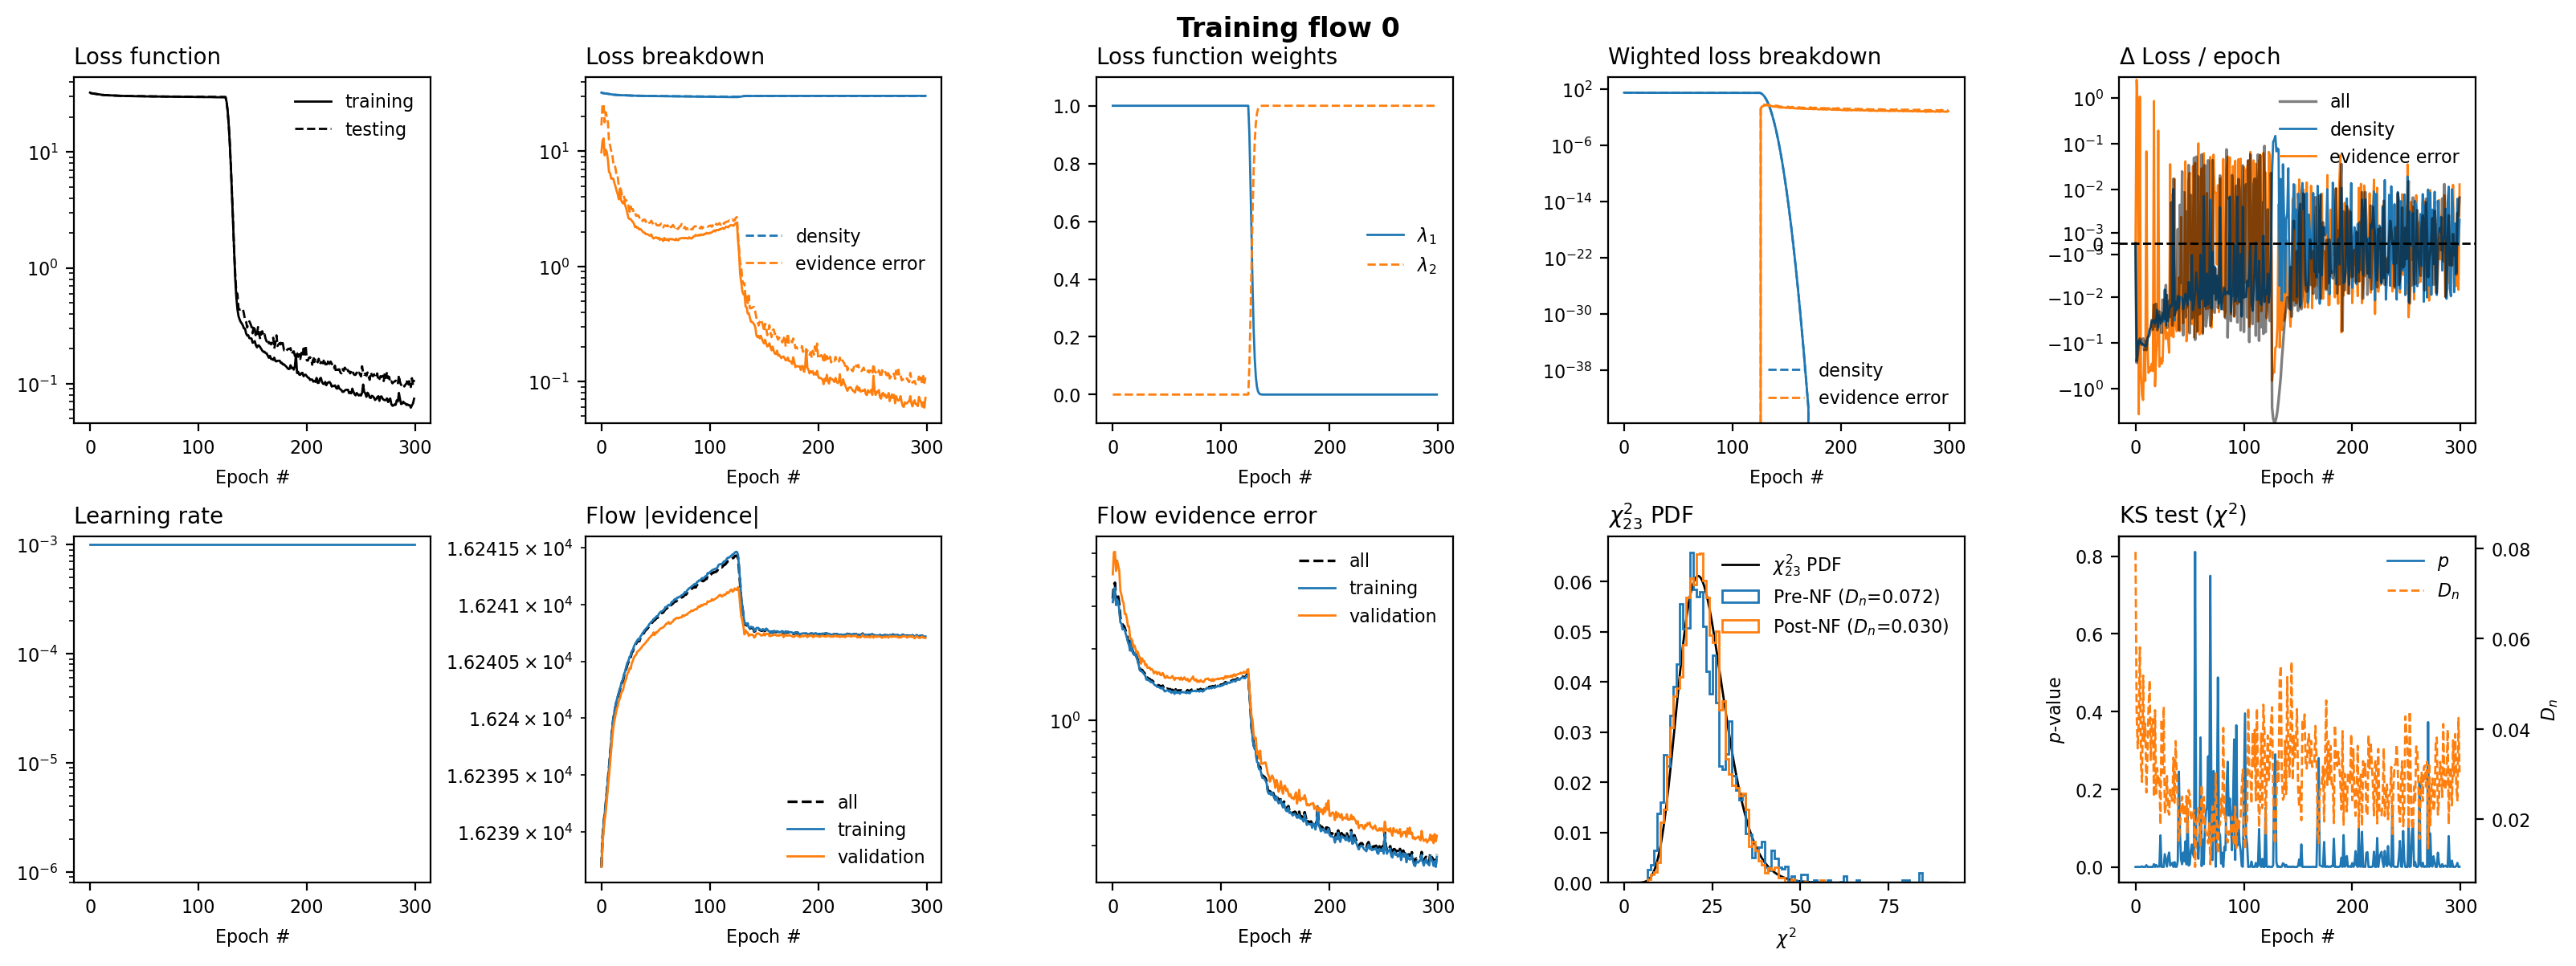

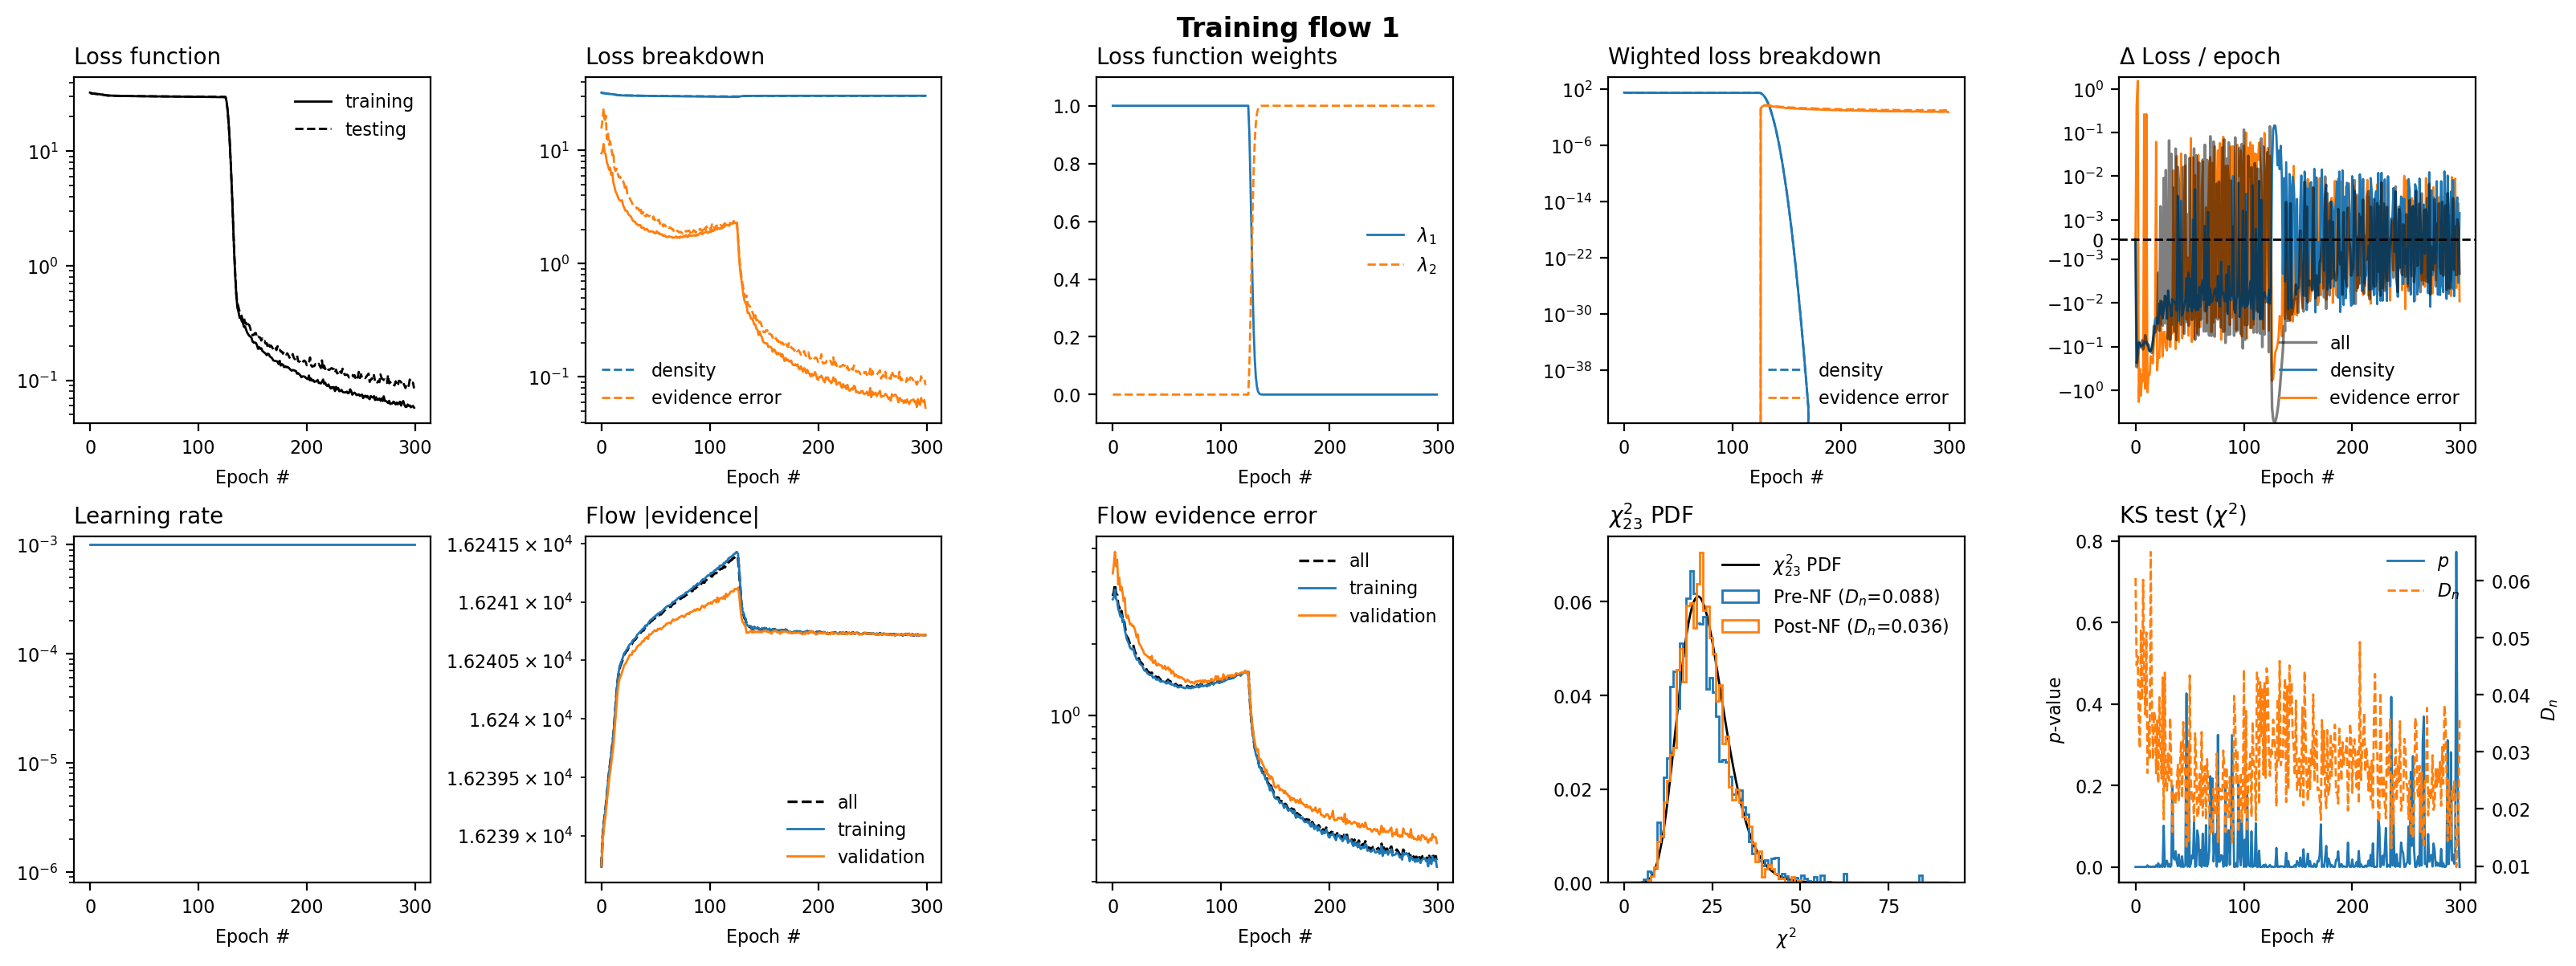

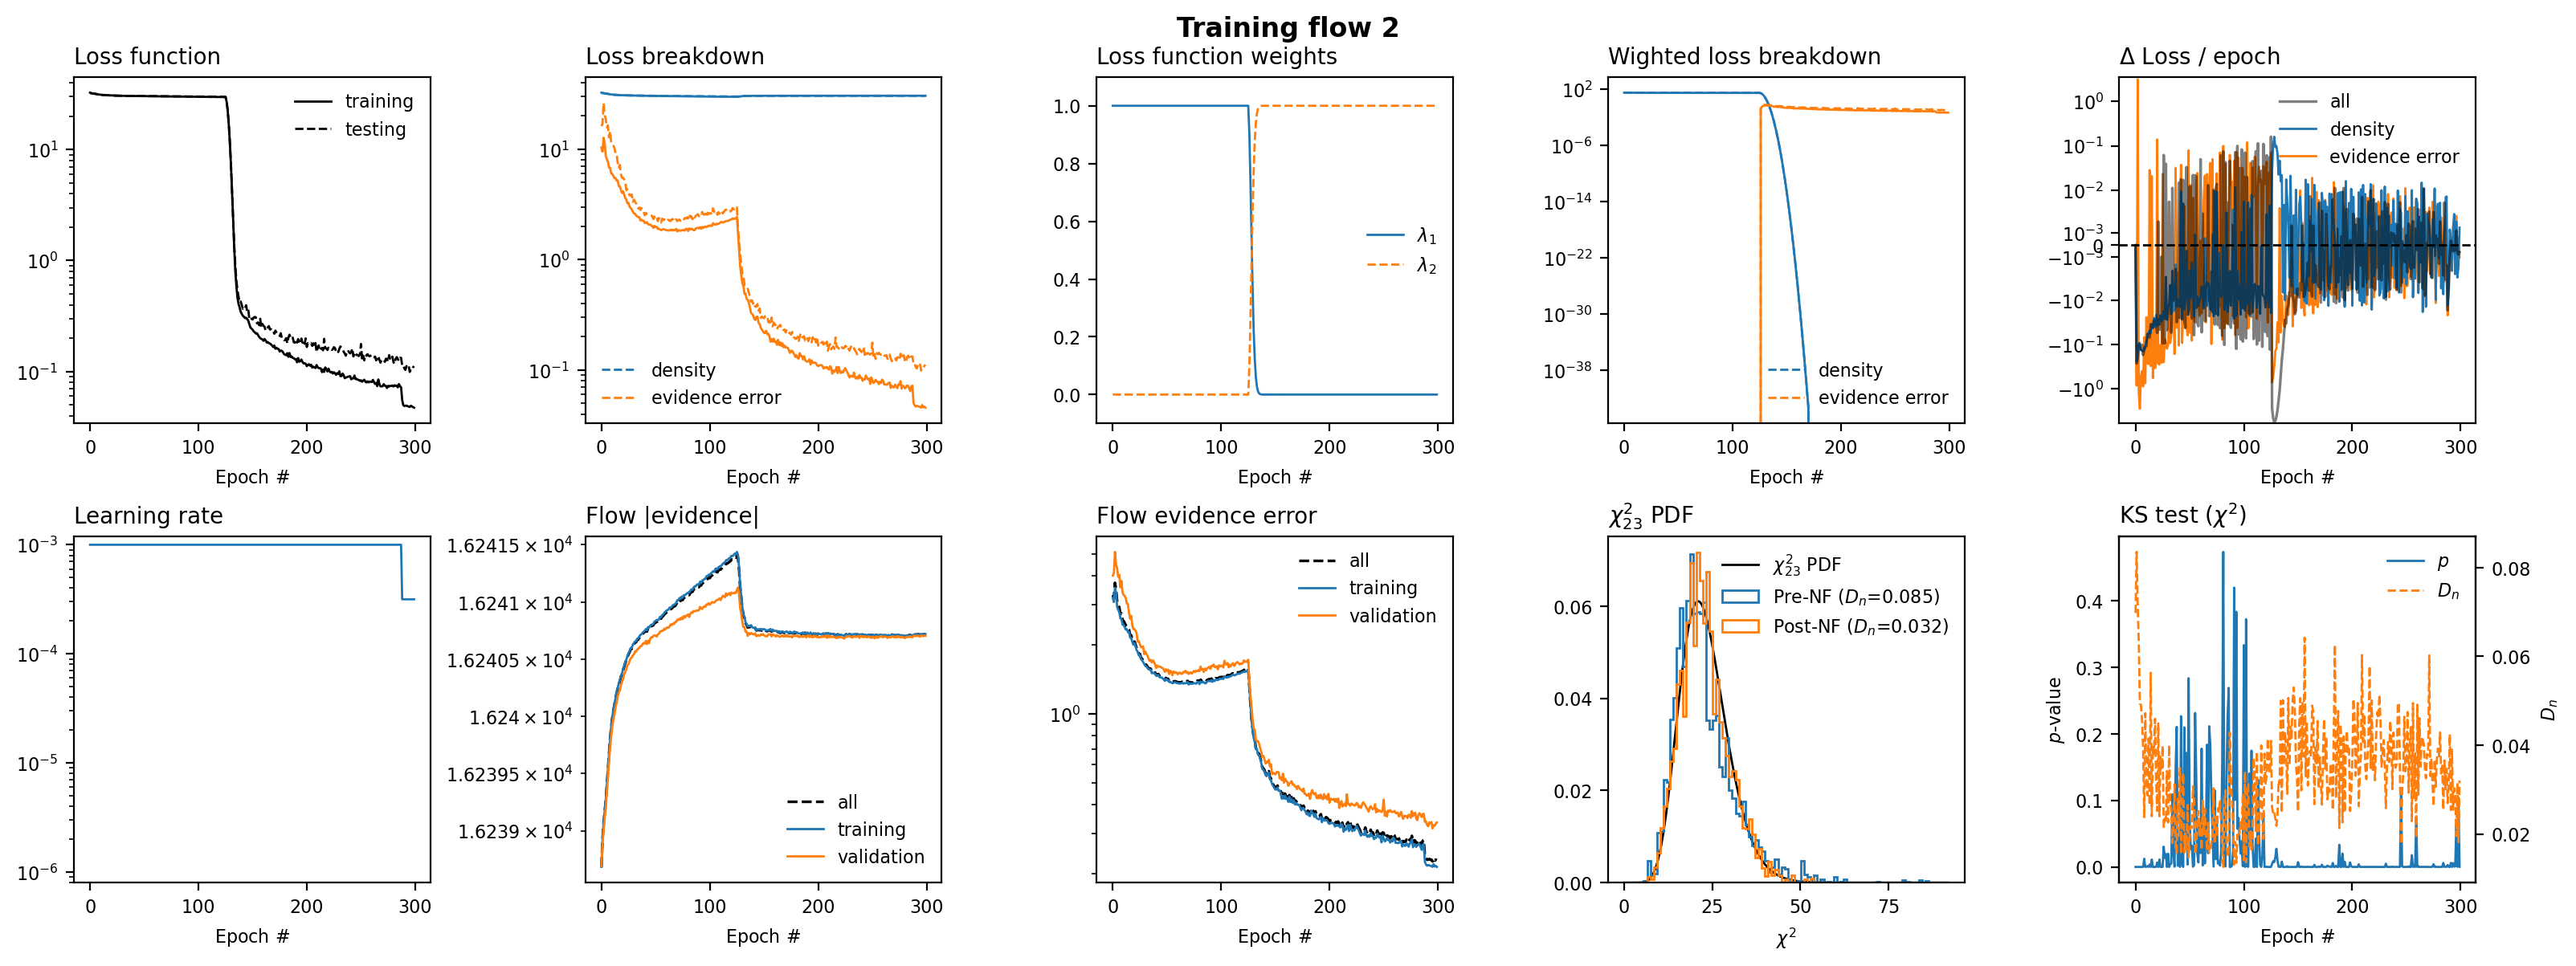

In [16]:
# most methods are implemented for the average flow as well:
average_flow_lcdm.training_plot()

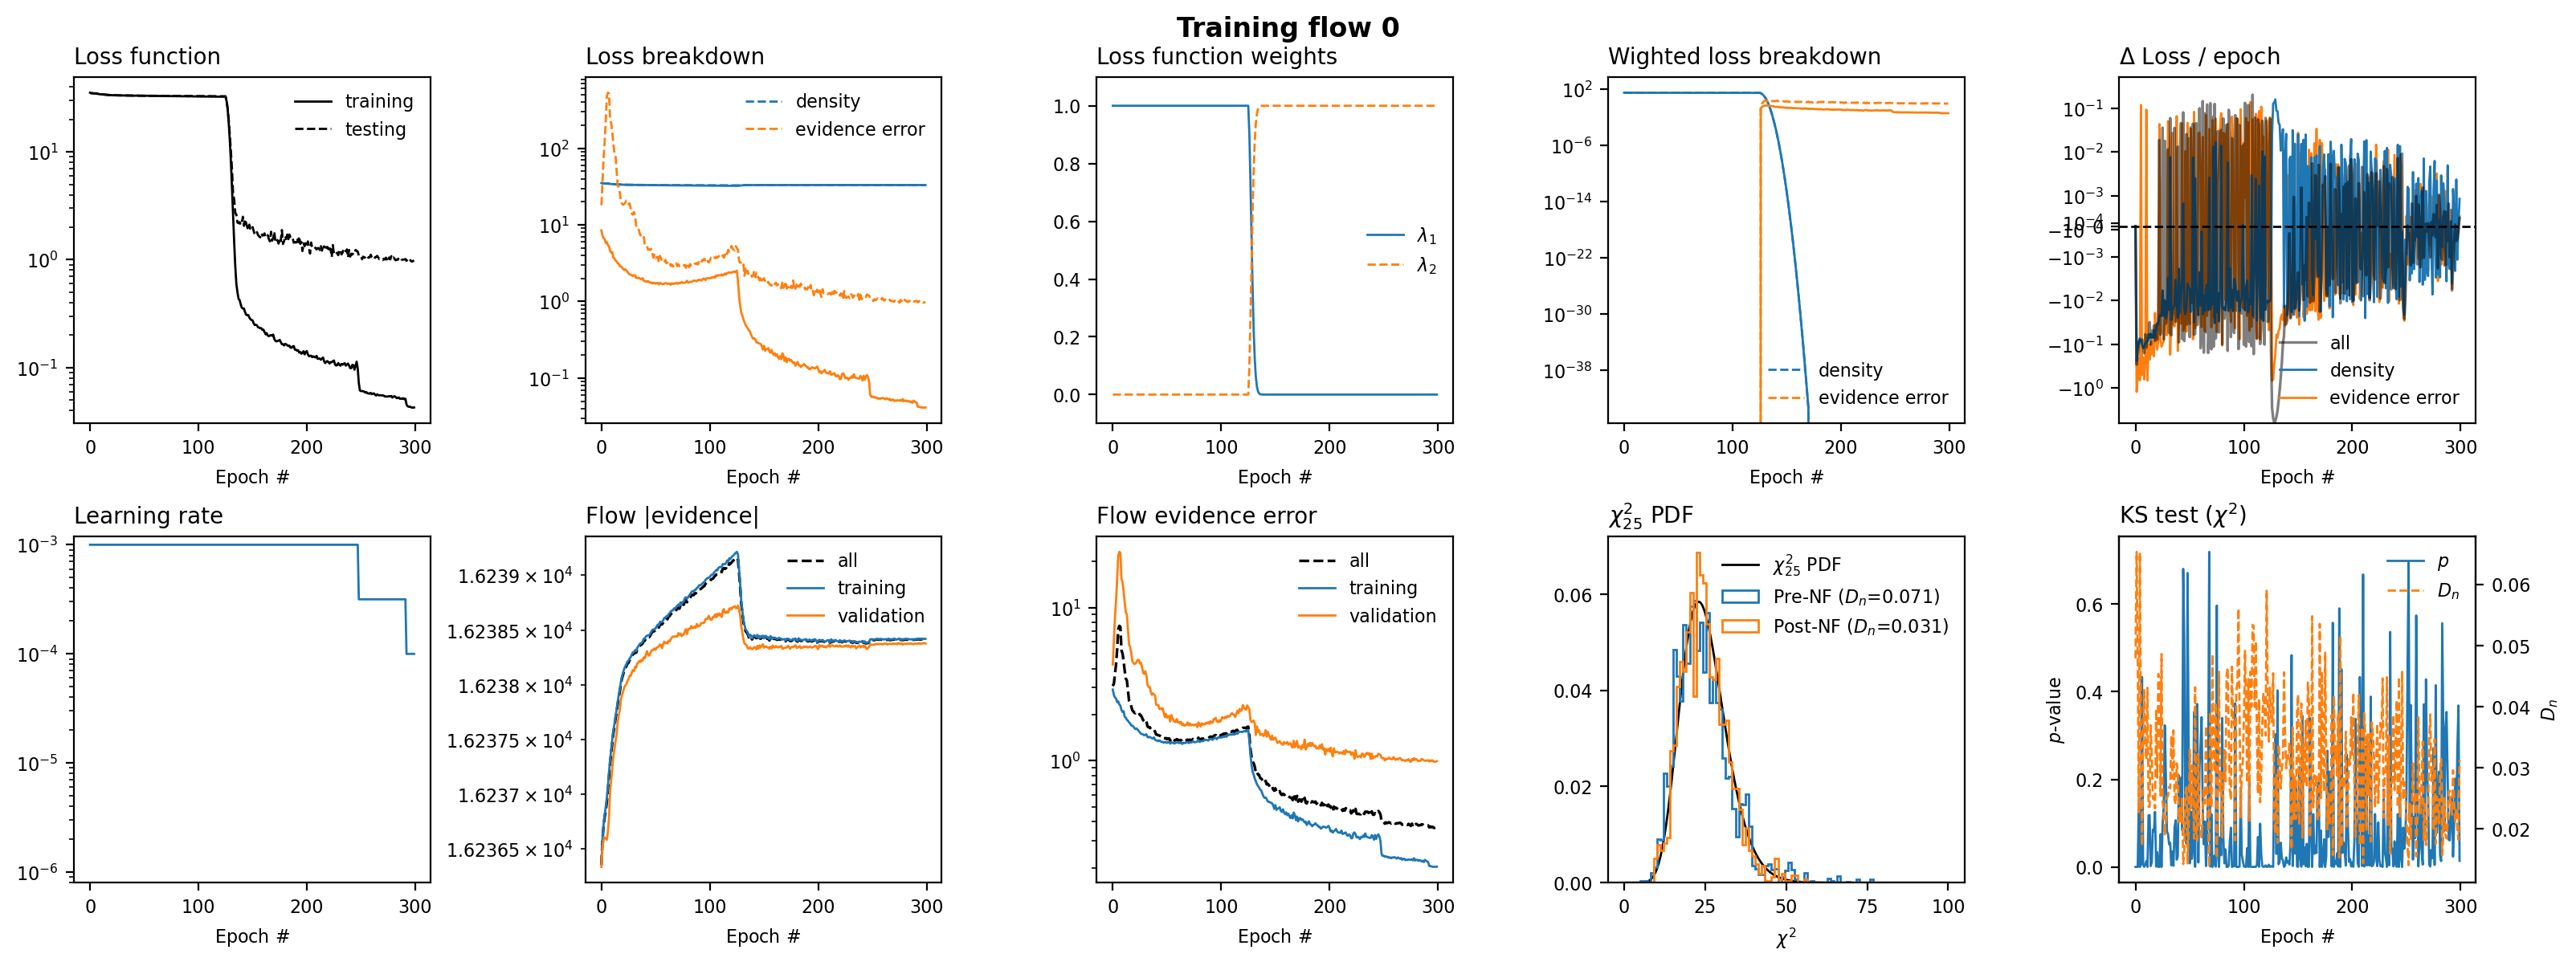

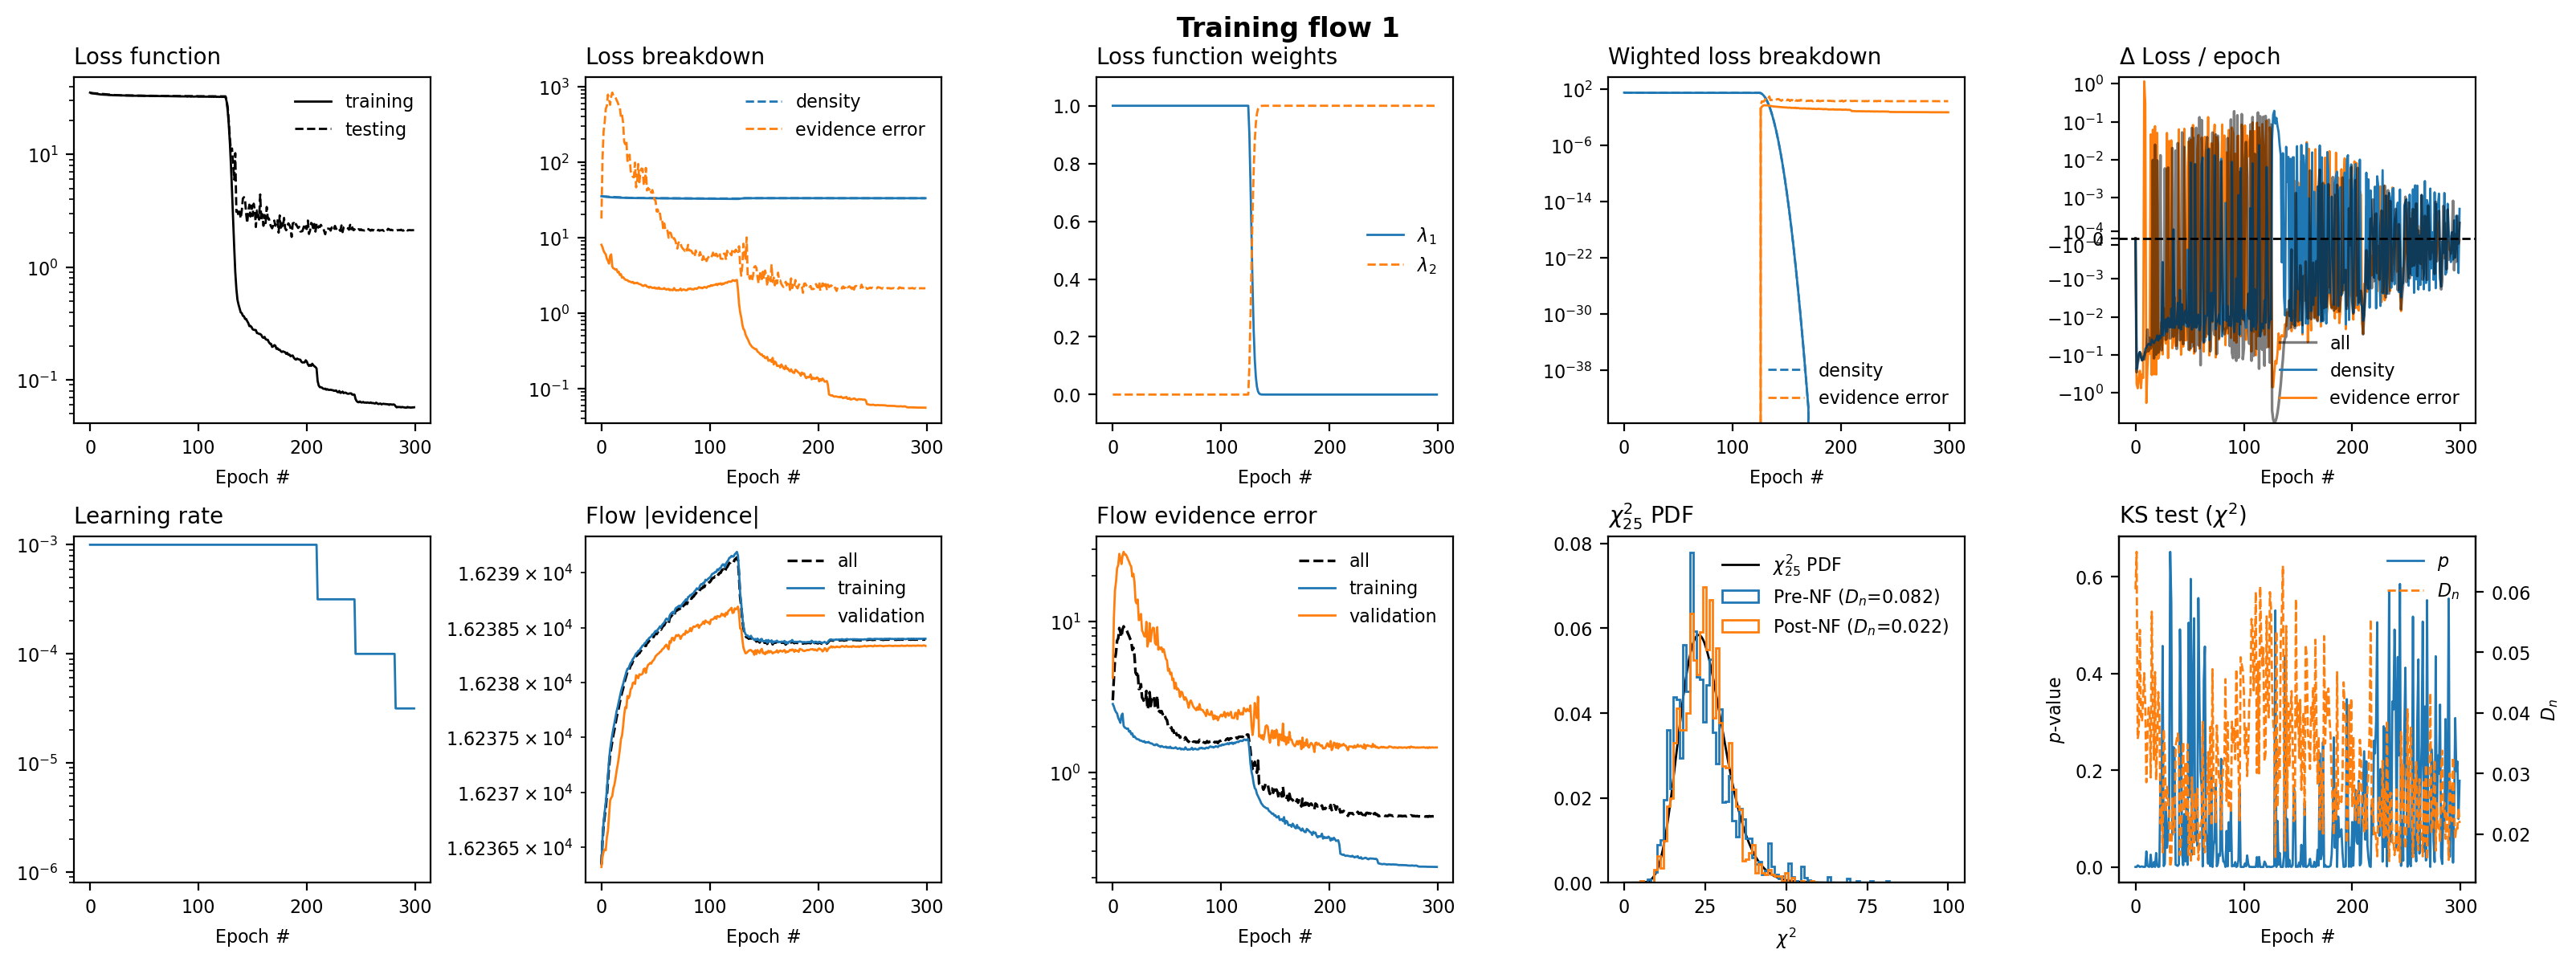

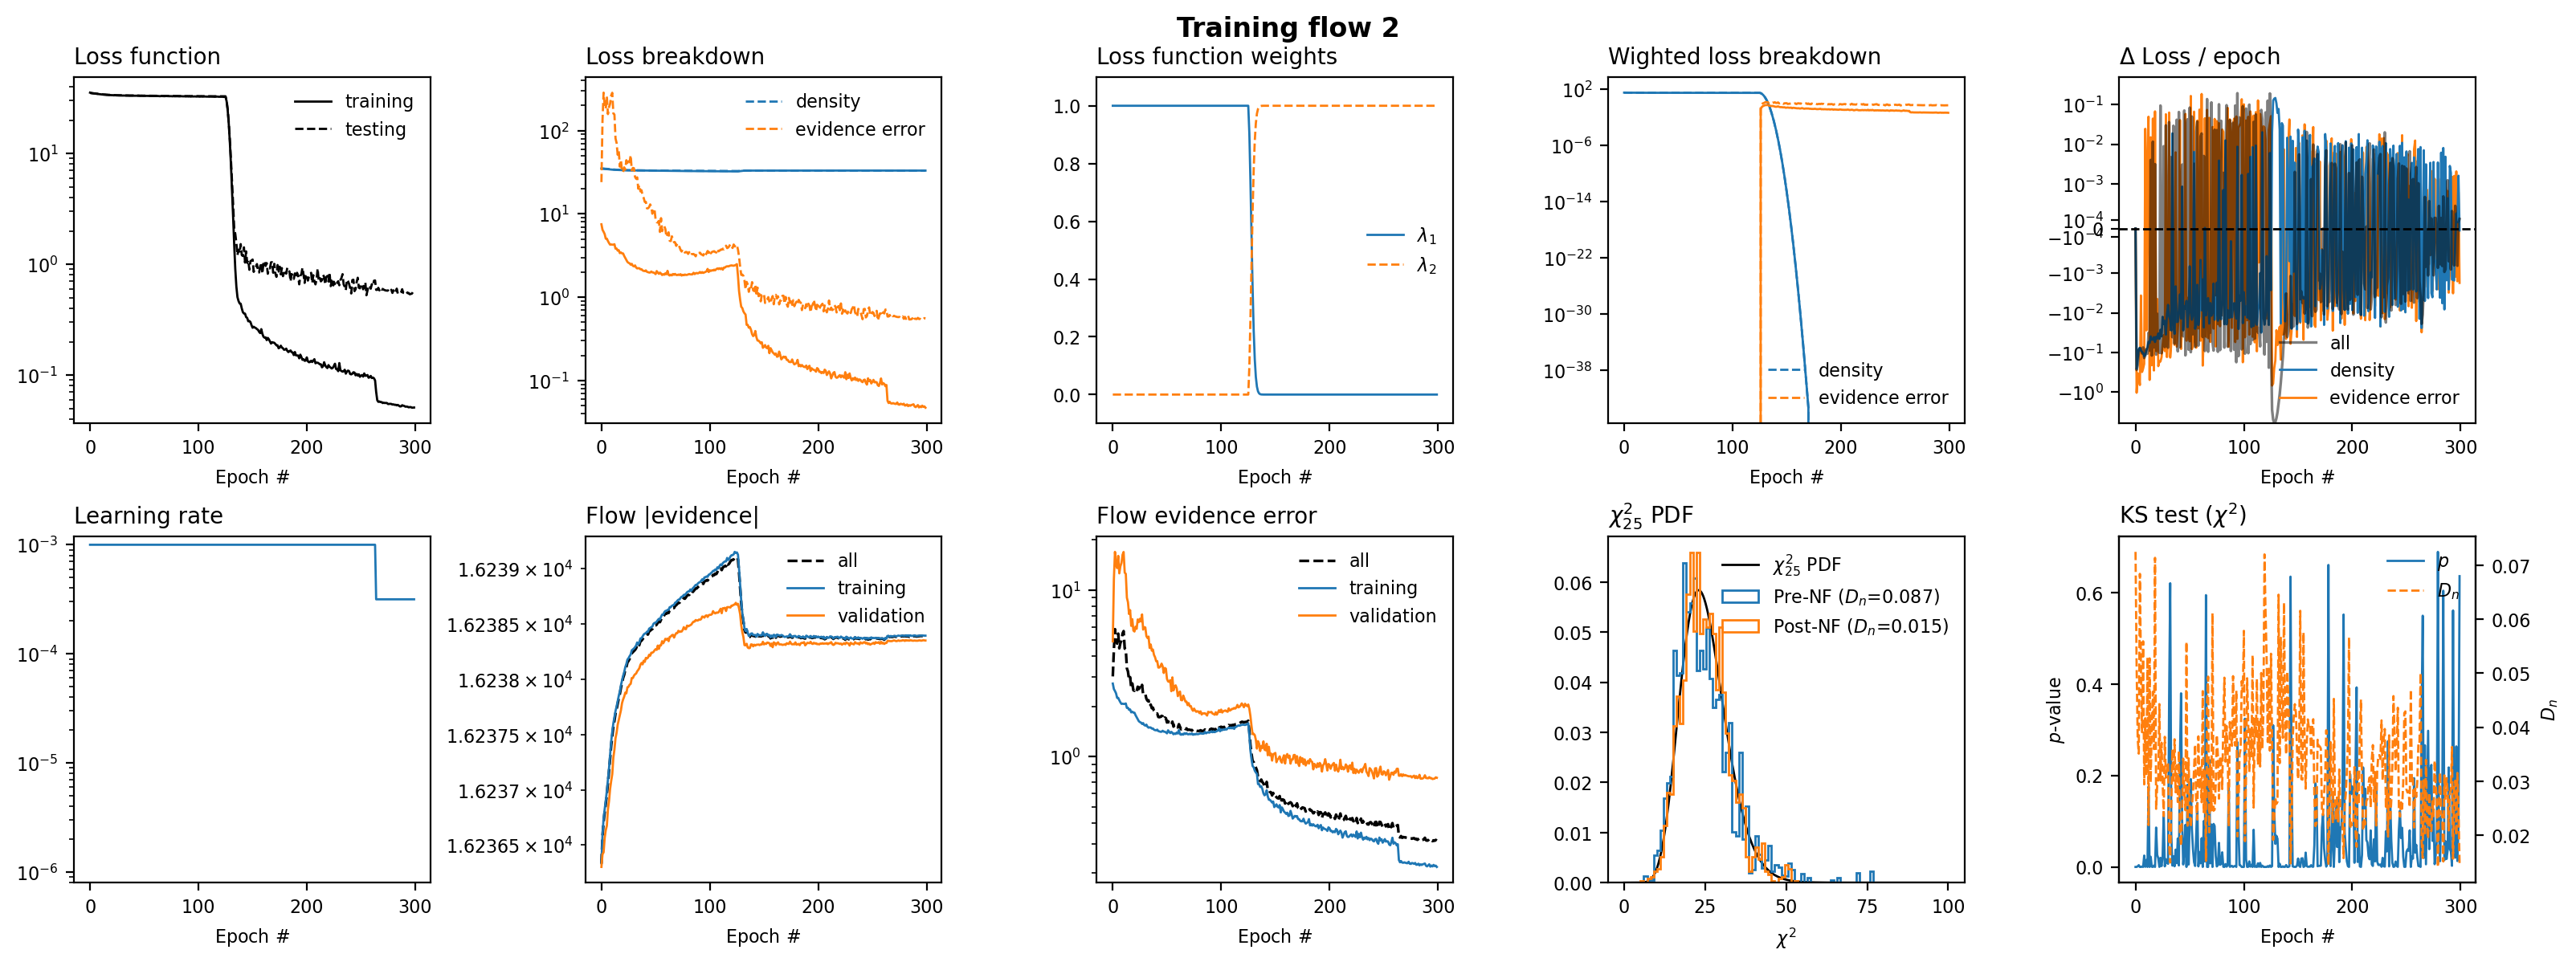

In [17]:
# most methods are implemented for the average flow as well:
average_flow_w0wa.training_plot()

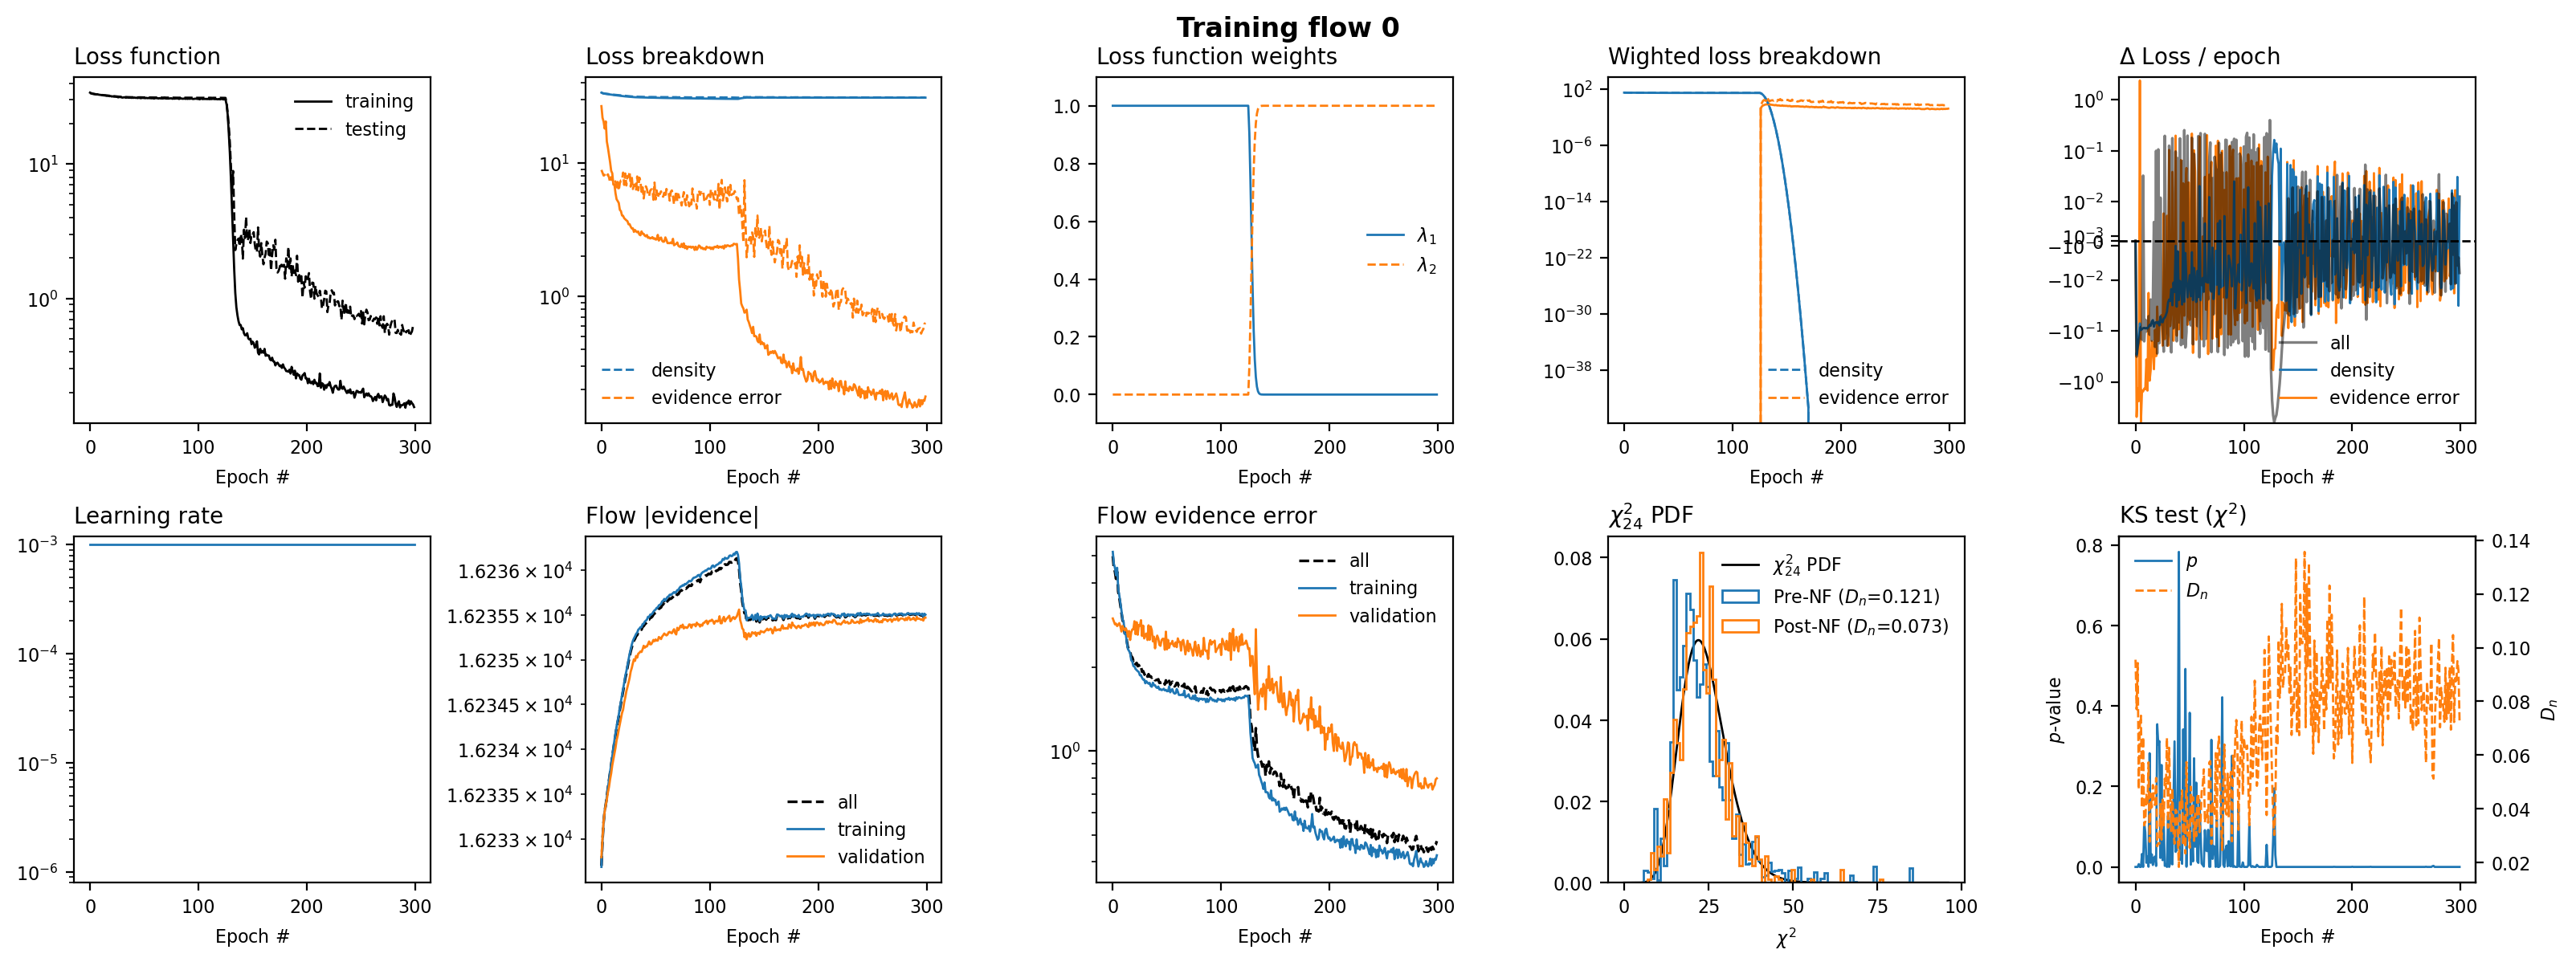

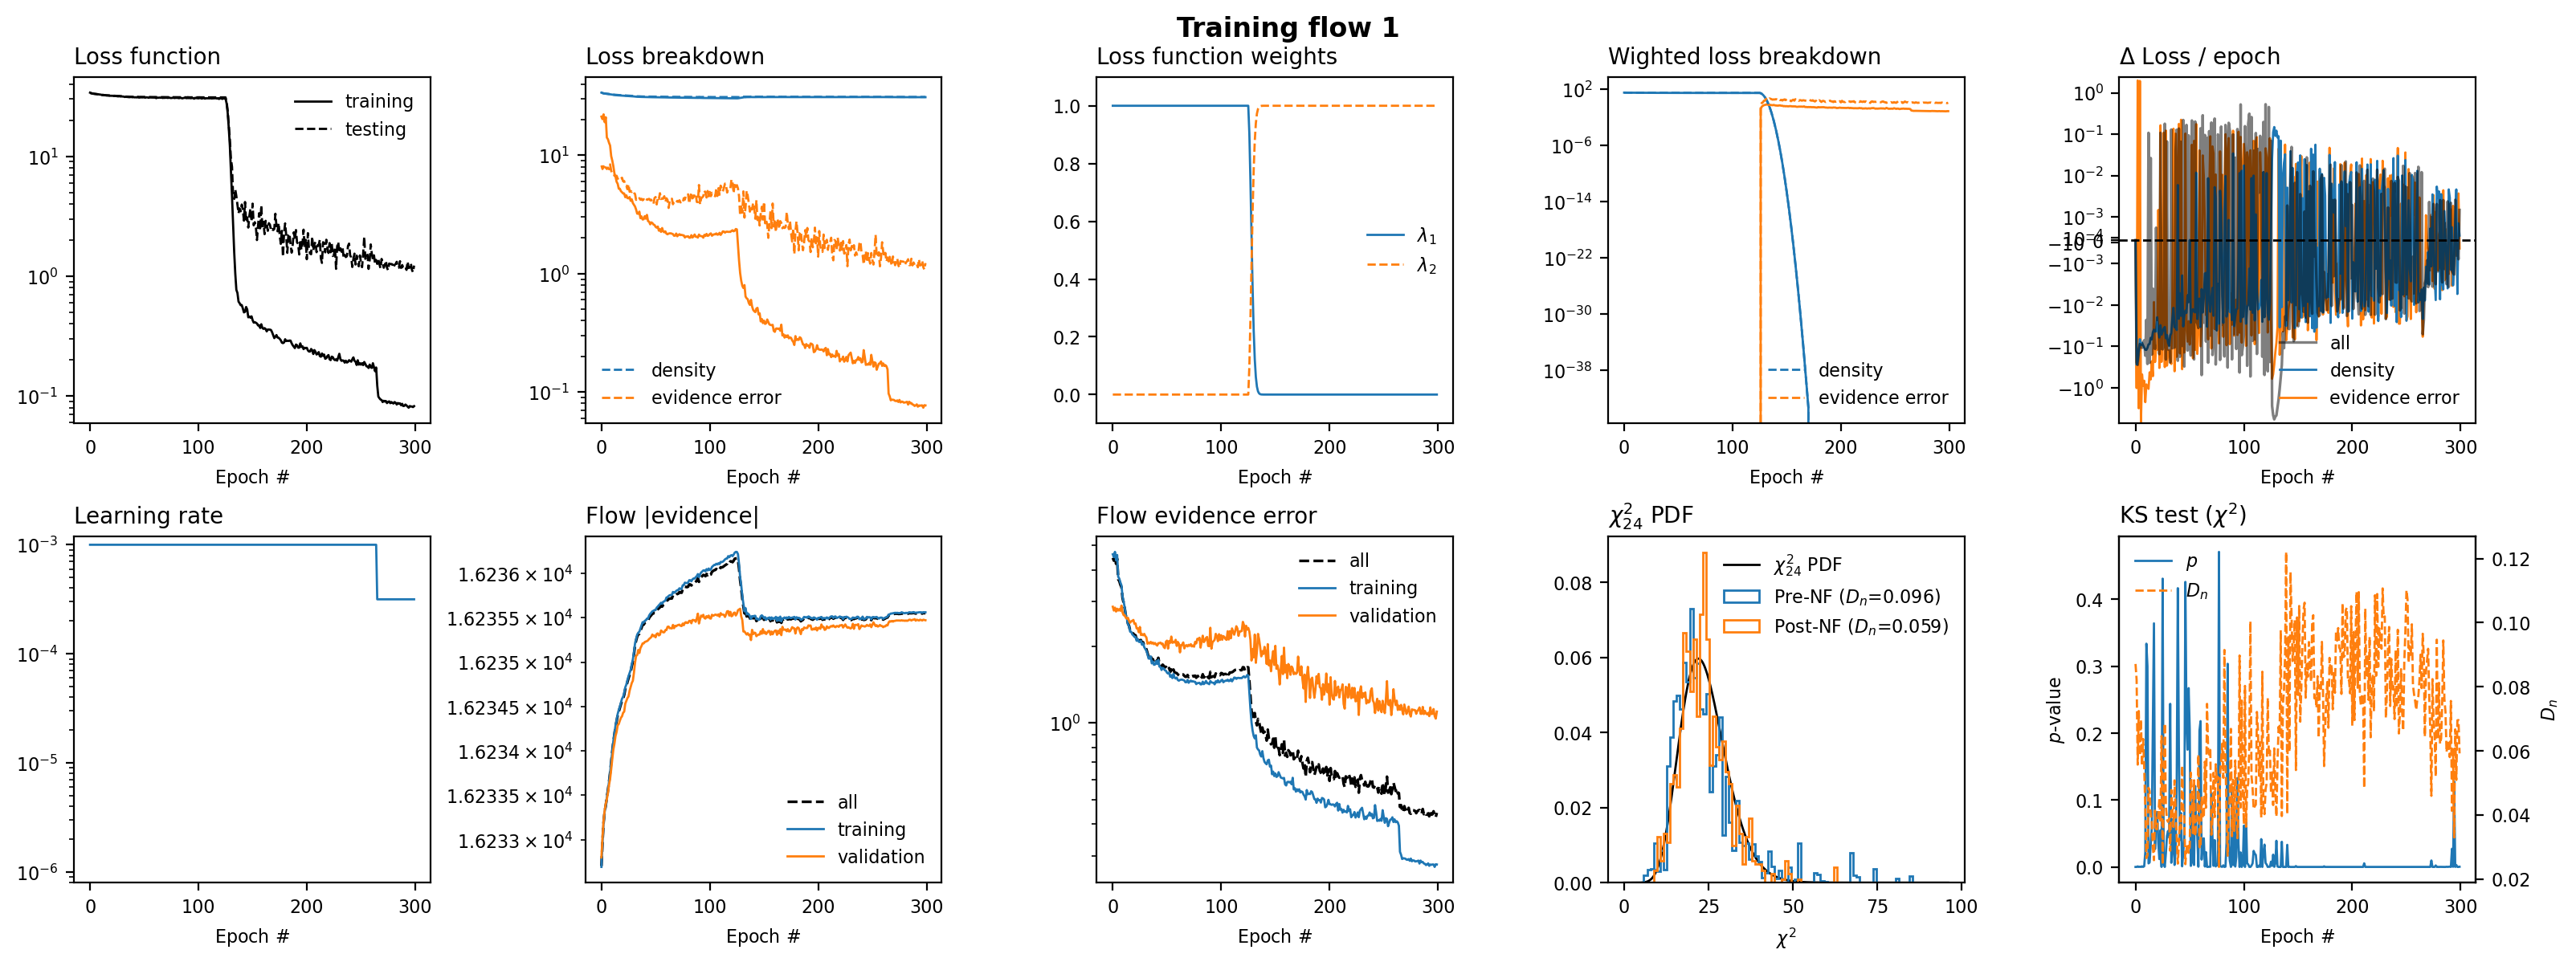

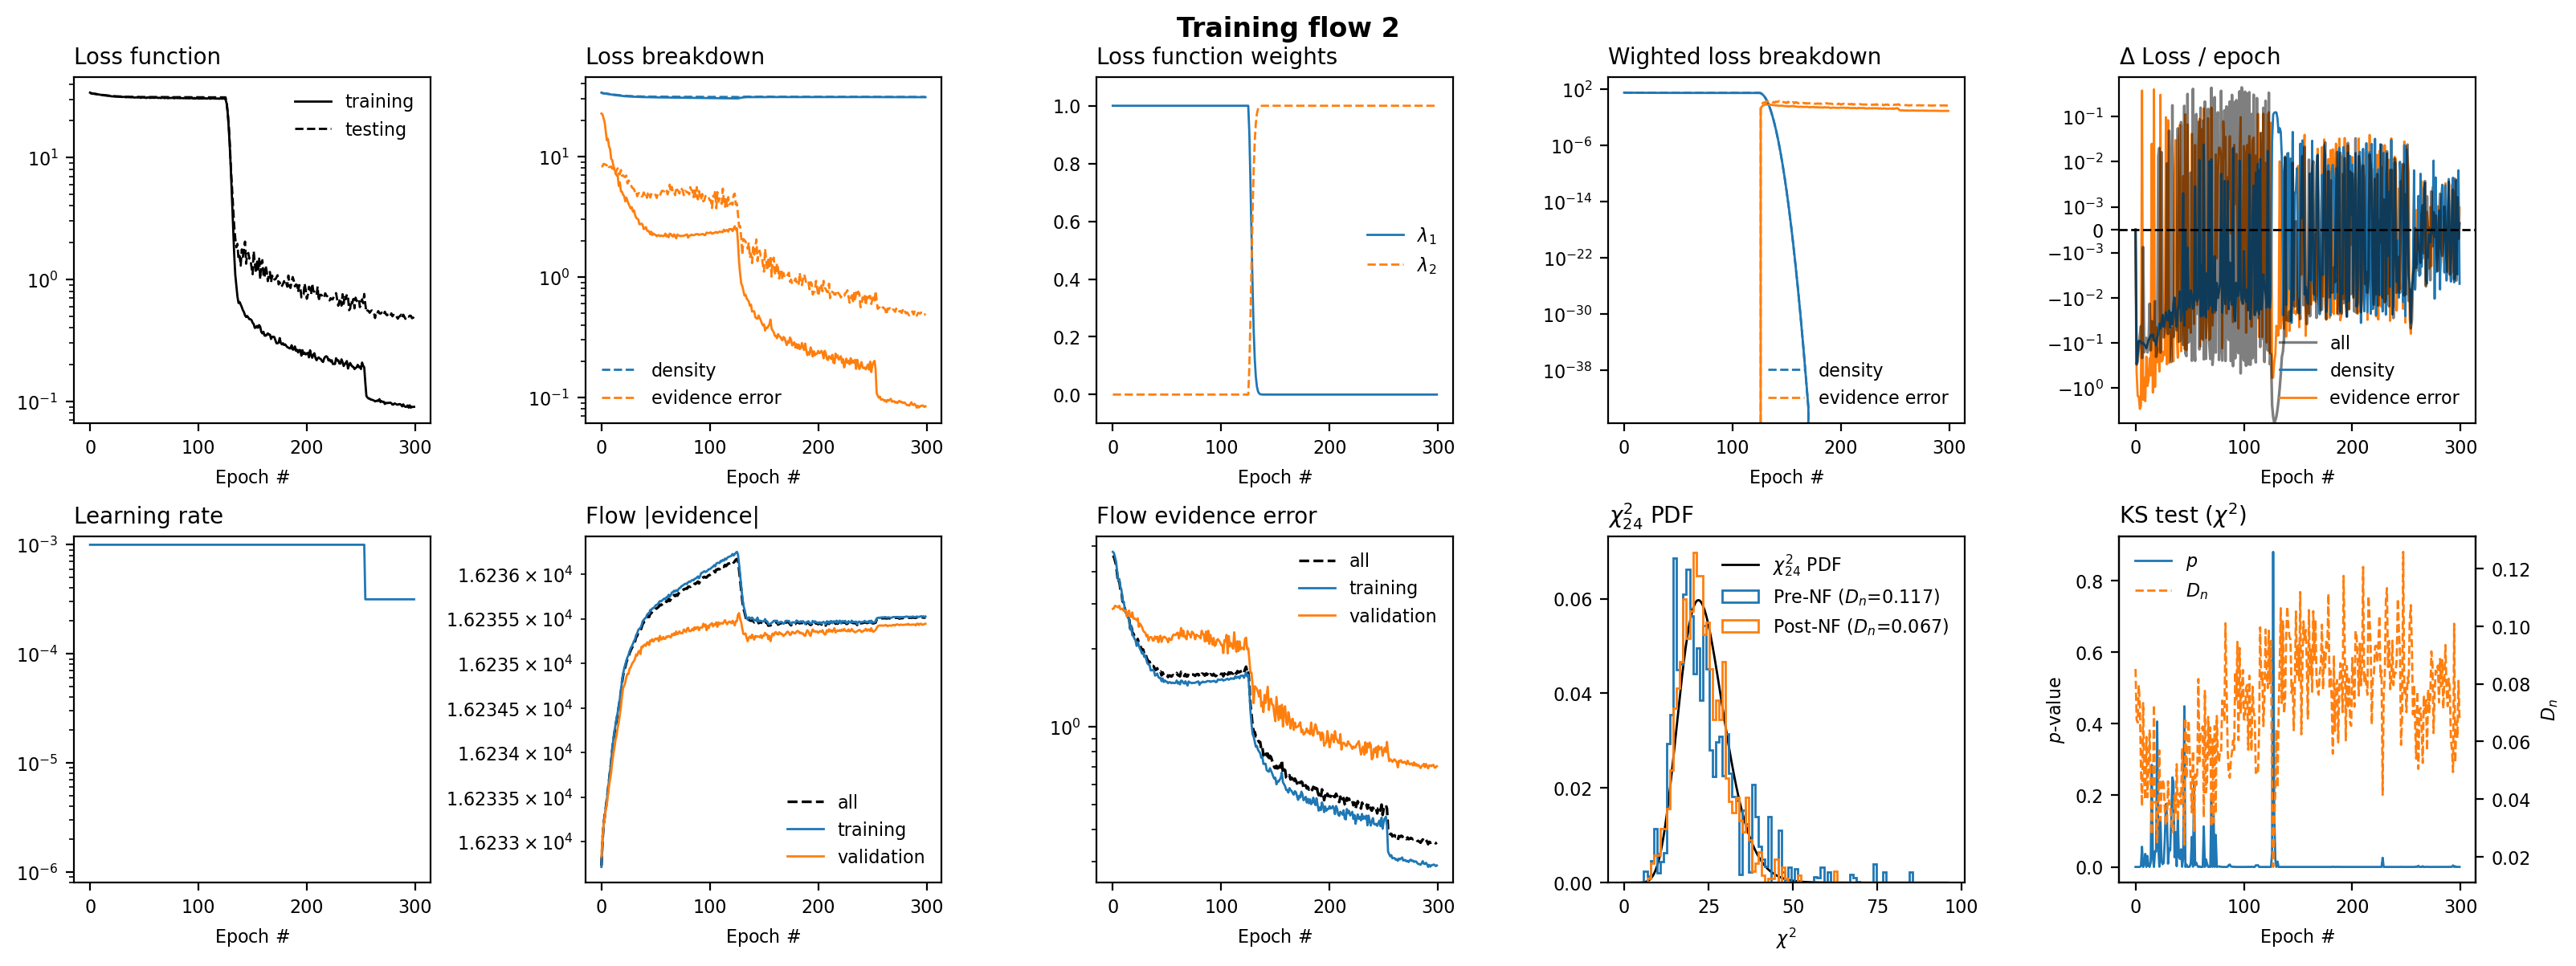

In [18]:
# most methods are implemented for the average flow as well:
average_flow_exp.training_plot()

In [19]:
# and we can print the training summary, which in this case contains more info:
average_flow_lcdm.print_training_summary()

Number of flows: 3
Flow weights   : [0.33 0.34 0.33]
loss                   : [0.07 0.06 0.05]
val_loss               : [0.11 0.08 0.11]
lr                     : [0. 0. 0.]
rho_loss               : [30.35 30.35 30.35]
ee_loss                : [0.07 0.05 0.05]
val_rho_loss           : [30.29 30.27 30.29]
val_ee_loss            : [0.11 0.08 0.11]
loss_rate              : [ 0.01 -0.   -0.  ]
rho_loss_rate          : [0. 0. 0.]
ee_loss_rate           : [ 0.01 -0.01 -0.  ]
chi2Z_ks               : [0.03 0.04 0.03]
chi2Z_ks_p             : [4.76e-04 2.14e-05 1.93e-04]
training_evidence      : [-16240.72 -16240.71 -16240.72]
training_evidence_error: [0.27 0.23 0.21]
test_evidence          : [-16240.71 -16240.72 -16240.7 ]
test_evidence_error    : [0.33 0.29 0.33]
evidence               : [-16240.71 -16240.71 -16240.72]
evidence_error         : [0.27 0.24 0.23]
lambda_1               : [0. 0. 0.]
lambda_2               : [1. 1. 1.]


In [20]:
# and we can print the training summary, which in this case contains more info:
average_flow_w0wa.print_training_summary()

Number of flows: 3
Flow weights   : [0.35 0.11 0.54]
loss                   : [0.04 0.06 0.05]
val_loss               : [0.99 2.13 0.56]
lr                     : [1.00e-04 3.16e-05 3.16e-04]
rho_loss               : [33.13 33.16 33.16]
ee_loss                : [0.04 0.06 0.05]
val_rho_loss           : [33.08 33.12 33.11]
val_ee_loss            : [0.99 2.13 0.56]
loss_rate              : [0. 0. 0.]
rho_loss_rate          : [ 8.51e-04  5.07e-04 -2.29e-05]
ee_loss_rate           : [ 2.91e-04 -2.16e-05 -1.75e-03]
chi2Z_ks               : [0.03 0.02 0.01]
chi2Z_ks_p             : [0.01 0.18 0.64]
training_evidence      : [-16238.42 -16238.4  -16238.39]
training_evidence_error: [0.2  0.24 0.22]
test_evidence          : [-16238.38 -16238.33 -16238.35]
test_evidence_error    : [0.99 1.46 0.75]
evidence               : [-16238.42 -16238.39 -16238.39]
evidence_error         : [0.37 0.51 0.31]
lambda_1               : [0. 0. 0.]
lambda_2               : [1. 1. 1.]


In [21]:
# and we can print the training summary, which in this case contains more info:
average_flow_exp.print_training_summary()

Number of flows: 3
Flow weights   : [0.37 0.2  0.43]
loss                   : [0.16 0.08 0.09]
val_loss               : [0.63 1.23 0.49]
lr                     : [0. 0. 0.]
rho_loss               : [31.02 30.96 31.  ]
ee_loss                : [0.18 0.08 0.08]
val_rho_loss           : [31.1  31.1  31.13]
val_ee_loss            : [0.63 1.23 0.5 ]
loss_rate              : [-0.01  0.    0.  ]
rho_loss_rate          : [ 0.01  0.   -0.  ]
ee_loss_rate           : [ 0.01 -0.    0.  ]
chi2Z_ks               : [0.07 0.06 0.07]
chi2Z_ks_p             : [3.38e-06 2.87e-04 2.34e-05]
training_evidence      : [-16235.5  -16235.56 -16235.52]
training_evidence_error: [0.42 0.28 0.29]
test_evidence          : [-16235.47 -16235.47 -16235.44]
test_evidence_error    : [0.8  1.11 0.7 ]
evidence               : [-16235.5  -16235.55 -16235.52]
evidence_error         : [0.47 0.44 0.36]
lambda_1               : [0. 0. 0.]
lambda_2               : [1. 1. 1.]


In [22]:
'''
avg_samples_lcdm = average_flow_lcdm.MCSamples(20000)
avg_samples_lcdm.name_tag = 'Average Flow LCDM'
temp_samples_lcdm = [_f.MCSamples(20000) for _f in average_flow_lcdm.flows]
for i, _s in enumerate(temp_samples_lcdm):
    _s.name_tag = _s.name_tag + f'_{i}'
# let's plot the flows:
g = plots.get_subplot_plotter()
g.triangle_plot([chain_lcdm, avg_samples_lcdm] + temp_samples_lcdm,
                filled=False)

avg_samples_w0wa = average_flow_w0wa.MCSamples(20000)
avg_samples_w0wa.name_tag = 'Average Flow W0WA'
temp_samples_w0wa = [_f.MCSamples(20000) for _f in average_flow_w0wa.flows]
for i, _s in enumerate(temp_samples_w0wa):
    _s.name_tag = _s.name_tag + f'_{i}'
# let's plot the flows:
g = plots.get_subplot_plotter()
g.triangle_plot([chain_w0wa, avg_samples_w0wa] + temp_samples_w0wa,
                filled=False)

avg_samples_exp = average_flow_exp.MCSamples(20000)
avg_samples_exp.name_tag = 'Average Flow EXP'
temp_samples_exp = [_f.MCSamples(20000) for _f in average_flow_exp.flows]
for i, _s in enumerate(temp_samples_exp):
    _s.name_tag = _s.name_tag + f'_{i}'
# let's plot the flows:
g = plots.get_subplot_plotter()
g.triangle_plot([chain_exp, avg_samples_exp] + temp_samples_exp,
                filled=False)
'''

"\navg_samples_lcdm = average_flow_lcdm.MCSamples(20000)\navg_samples_lcdm.name_tag = 'Average Flow LCDM'\ntemp_samples_lcdm = [_f.MCSamples(20000) for _f in average_flow_lcdm.flows]\nfor i, _s in enumerate(temp_samples_lcdm):\n    _s.name_tag = _s.name_tag + f'_{i}'\n# let's plot the flows:\ng = plots.get_subplot_plotter()\ng.triangle_plot([chain_lcdm, avg_samples_lcdm] + temp_samples_lcdm,\n                filled=False)\n\navg_samples_w0wa = average_flow_w0wa.MCSamples(20000)\navg_samples_w0wa.name_tag = 'Average Flow W0WA'\ntemp_samples_w0wa = [_f.MCSamples(20000) for _f in average_flow_w0wa.flows]\nfor i, _s in enumerate(temp_samples_w0wa):\n    _s.name_tag = _s.name_tag + f'_{i}'\n# let's plot the flows:\ng = plots.get_subplot_plotter()\ng.triangle_plot([chain_w0wa, avg_samples_w0wa] + temp_samples_w0wa,\n                filled=False)\n\navg_samples_exp = average_flow_exp.MCSamples(20000)\navg_samples_exp.name_tag = 'Average Flow EXP'\ntemp_samples_exp = [_f.MCSamples(20000) for _

In [23]:
ev_lcdm, eer_lcdm = average_flow_lcdm.evidence(weighted=True)
print(f'LCDM: log(Z) = {ev_lcdm} +- {eer_lcdm}')

ev_w0wa, eer_w0wa = average_flow_w0wa.evidence(weighted=True)
print(f'W0WA: log(Z) = {ev_w0wa} +- {eer_w0wa}')

ev_exp, eer_exp = average_flow_exp.evidence(weighted=True)
print(f'EXP: log(Z) = {ev_exp} +- {eer_exp}')

LCDM: log(Z) = -16240.722767126892 +- 0.15660437786652204
W0WA: log(Z) = -16238.404269817145 +- 0.2037606202986325
EXP: log(Z) = -16235.536069790505 +- 0.2518576725826476
